In [1]:
import os
from dotenv import load_dotenv
import pandas as pd
import glob
import pyproj
import math

# visualisations
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np

In [2]:
'''
load_dotenv()

os.environ['KAGGLE_USERNAME'] = 'thisisbeancurd' 
os.environ['KAGGLE_KEY'] = 'f4ab12e676a945cc00bd067acbcc2c50'

from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()
'''

In [2]:
%store -r gnss_df

In [2]:
parent_folder = "../train"

# retrieve device.imu files from train
gnss_files = glob.glob(os.path.join(parent_folder, "*", "*", "device_gnss.csv"))
print(gnss_files) 

['../train/2021-01-04-US-SFO-2/GooglePixel5/device_gnss.csv', '../train/2021-01-04-US-SFO-2/XiaomiMi8/device_gnss.csv', '../train/2021-01-04-US-SFO-2/GooglePixel4/device_gnss.csv', '../train/2021-01-04-US-SFO-2/GooglePixel4XL/device_gnss.csv', '../train/2020-05-21-US-MTV-1/GooglePixel4/device_gnss.csv', '../train/2020-05-21-US-MTV-1/GooglePixel4XL/device_gnss.csv', '../train/2021-04-21-US-MTV-2/XiaomiMi8/device_gnss.csv', '../train/2021-04-21-US-MTV-2/SamsungGalaxyS20Ultra/device_gnss.csv', '../train/2020-11-23-US-MTV-1/XiaomiMi8/device_gnss.csv', '../train/2020-06-18-US-MTV-1/GooglePixel4/device_gnss.csv', '../train/2020-06-18-US-MTV-1/GooglePixel4XL/device_gnss.csv', '../train/2020-07-24-US-MTV-1/GooglePixel5/device_gnss.csv', '../train/2020-07-24-US-MTV-1/GooglePixel4/device_gnss.csv', '../train/2020-07-24-US-MTV-1/GooglePixel4XL/device_gnss.csv', '../train/2020-05-15-US-MTV-1/GooglePixel4XL/device_gnss.csv', '../train/2020-06-05-US-MTV-1/GooglePixel4/device_gnss.csv', '../train/202

In [4]:
gnss_list = []

for file in gnss_files:
    gnss_file = pd.read_csv(file)
    parts = file.split(os.sep) # eg ['train', '2021-12-28-US-MTV-1', 'GooglePixel5', 'device_imu.csv']
    gnss_file["drive_id"] = parts[-3] 
    gnss_file["device"] = parts[-2]
    gnss_list.append(gnss_file)

# combine all
gnss_df = pd.concat(gnss_list, ignore_index=True)
print(gnss_df.head())
print()
print(gnss_df["device"].unique())
print()
print(gnss_df["drive_id"].unique())

/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_8433/1769875542.py:4: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  gnss_file = pd.read_csv(file)


  MessageType  utcTimeMillis       TimeNanos  LeapSecond        FullBiasNanos  \
0         Raw  1609800004433  10686613000000        18.0 -1293824535820307301   
1         Raw  1609800004433  10686613000000        18.0 -1293824535820307301   
2         Raw  1609800004433  10686613000000        18.0 -1293824535820307301   
3         Raw  1609800004433  10686613000000        18.0 -1293824535820307301   
4         Raw  1609800004433  10686613000000        18.0 -1293824535820307301   

   BiasNanos  BiasUncertaintyNanos  DriftNanosPerSecond  \
0  -0.133871             25.289228            -9.770029   
1  -0.133871             25.289228            -9.770029   
2  -0.133871             25.289228            -9.770029   
3  -0.133871             25.289228            -9.770029   
4  -0.133871             25.289228            -9.770029   

   DriftUncertaintyNanosPerSecond  HardwareClockDiscontinuityCount  ...  \
0                         9.47592                               50  ...   
1       

In [3]:
%store -r gt_df

In [5]:
parent_folder = "../train"

# retrieve device.imu files from train
gt_files = glob.glob(os.path.join(parent_folder, "*", "*", "ground_truth.csv"))
print(gt_files) 

['../train/2021-01-04-US-SFO-2/GooglePixel5/ground_truth.csv', '../train/2021-01-04-US-SFO-2/XiaomiMi8/ground_truth.csv', '../train/2021-01-04-US-SFO-2/GooglePixel4/ground_truth.csv', '../train/2021-01-04-US-SFO-2/GooglePixel4XL/ground_truth.csv', '../train/2020-05-21-US-MTV-1/GooglePixel4/ground_truth.csv', '../train/2020-05-21-US-MTV-1/GooglePixel4XL/ground_truth.csv', '../train/2021-04-21-US-MTV-2/XiaomiMi8/ground_truth.csv', '../train/2021-04-21-US-MTV-2/SamsungGalaxyS20Ultra/ground_truth.csv', '../train/2020-11-23-US-MTV-1/XiaomiMi8/ground_truth.csv', '../train/2020-06-18-US-MTV-1/GooglePixel4/ground_truth.csv', '../train/2020-06-18-US-MTV-1/GooglePixel4XL/ground_truth.csv', '../train/2020-07-24-US-MTV-1/GooglePixel5/ground_truth.csv', '../train/2020-07-24-US-MTV-1/GooglePixel4/ground_truth.csv', '../train/2020-07-24-US-MTV-1/GooglePixel4XL/ground_truth.csv', '../train/2020-05-15-US-MTV-1/GooglePixel4XL/ground_truth.csv', '../train/2020-06-05-US-MTV-1/GooglePixel4/ground_truth.csv

In [6]:
gt_list = []

for file in gt_files:
    gt_file = pd.read_csv(file)
    parts = file.split(os.sep) # eg ['train', '2021-12-28-US-MTV-1', 'GooglePixel5', 'device_imu.csv']
    gt_file["drive_id"] = parts[-3] 
    gt_file["device"] = parts[-2]
    gt_list.append(gt_file)

# combine all
gt_df = pd.concat(gt_list, ignore_index=True)
print(gt_df.head())
print()
print(gt_df["device"].unique())
print()
print(gt_df["drive_id"].unique())

  MessageType Provider  LatitudeDegrees  LongitudeDegrees  AltitudeMeters  \
0         Fix       GT        37.444387       -122.232673          11.581   
1         Fix       GT        37.444387       -122.232673          11.581   
2         Fix       GT        37.444387       -122.232673          11.582   
3         Fix       GT        37.444387       -122.232673          11.582   
4         Fix       GT        37.444387       -122.232673          11.582   

   SpeedMps  AccuracyMeters  BearingDegrees  UnixTimeMillis  \
0  0.001000             0.1       302.57940   1609800004433   
1  0.001276             0.1       302.57977   1609800005433   
2  0.000667             0.1       302.57830   1609800006433   
3  0.001824             0.1       302.57990   1609800007433   
4  0.001962             0.1       302.58002   1609800008433   

              drive_id        device  
0  2021-01-04-US-SFO-2  GooglePixel5  
1  2021-01-04-US-SFO-2  GooglePixel5  
2  2021-01-04-US-SFO-2  GooglePixel5  
3 

In [4]:
# 1. Setup the Transformer
# EPSG:4326 is standard Lat/Lon (WGS84)
# EPSG:4978 is standard ECEF (WGS84)
transformer = pyproj.Transformer.from_crs("epsg:4326", "epsg:4978", always_xy=True)

def get_ecef(df_gt):
    x, y = transformer.transform(
        df_gt['LongitudeDegrees'].values, 
        df_gt['LatitudeDegrees'].values, 
#        df_gt['AltitudeMeters'].values
    )
    
    df_gt['GroundTruthXEcefMeters'] = x
    df_gt['GroundTruthYEcefMeters'] = y
#    df_gt['GroundTruthZEcefMeters'] = z
    return df_gt

def get_wls_val(df_gt, df_gnss):
    gnss_grp_df = df_gnss.groupby(
        ['utcTimeMillis', 'drive_id', 'device'],
        as_index=False
    )[[
        'WlsPositionXEcefMeters',
        'WlsPositionYEcefMeters',
#        'WlsPositionZEcefMeters'
    ]].first()
    
    gnss_renamed_df = gnss_grp_df.rename(columns={"utcTimeMillis": "UnixTimeMillis"})

    df_merge = df_gt.merge(gnss_renamed_df[['UnixTimeMillis', 'WlsPositionXEcefMeters', 'WlsPositionYEcefMeters', 'drive_id', 'device']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
    
    return df_merge 

def get_target_var(df_gt):
    df_gt['ErrorXEcefMeters'] = df_gt['GroundTruthXEcefMeters'] - df_gt['WlsPositionXEcefMeters']
    df_gt['ErrorYEcefMeters'] = df_gt['GroundTruthYEcefMeters'] - df_gt['WlsPositionYEcefMeters']
#    df_gt['ErrorZEcefMeters'] = df_gt['GroundTruthZEcefMeters'] - df_gt['WlsPositionZEcefMeters']
    
    return df_gt


# convert lat/lon to ecef
gt_df = get_ecef(gt_df)

# clone df
target_df = gt_df.copy()

# get wls_val 
target_df = get_wls_val(target_df, gnss_df)

# get x, y, z error
target_df = get_target_var(target_df)

print(target_df.head())

   UnixTimeMillis        device             drive_id  LatitudeDegrees  \
0   1609800004433  GooglePixel5  2021-01-04-US-SFO-2        37.444387   
1   1609800005433  GooglePixel5  2021-01-04-US-SFO-2        37.444387   
2   1609800006433  GooglePixel5  2021-01-04-US-SFO-2        37.444387   
3   1609800007433  GooglePixel5  2021-01-04-US-SFO-2        37.444387   
4   1609800008433  GooglePixel5  2021-01-04-US-SFO-2        37.444387   

   LongitudeDegrees  GroundTruthXEcefMeters  GroundTruthYEcefMeters  \
0       -122.232673           -2.704214e+06           -4.288793e+06   
1       -122.232673           -2.704214e+06           -4.288793e+06   
2       -122.232673           -2.704214e+06           -4.288793e+06   
3       -122.232673           -2.704214e+06           -4.288793e+06   
4       -122.232673           -2.704214e+06           -4.288793e+06   

   WlsPositionXEcefMeters  WlsPositionYEcefMeters  ErrorXEcefMeters  \
0           -2.704222e+06           -4.288803e+06          8.05

In [6]:
print(target_df.isna().sum())

UnixTimeMillis             0
device                     0
drive_id                   0
LatitudeDegrees            0
LongitudeDegrees           0
GroundTruthXEcefMeters     0
GroundTruthYEcefMeters     0
WlsPositionXEcefMeters    33
WlsPositionYEcefMeters    33
ErrorXEcefMeters          33
ErrorYEcefMeters          33
dtype: int64


In [7]:
target_df = target_df.dropna(subset=['WlsPositionXEcefMeters'])
target_df = target_df.dropna(subset=['WlsPositionYEcefMeters'])

print(target_df.isna().sum())

UnixTimeMillis            0
device                    0
drive_id                  0
LatitudeDegrees           0
LongitudeDegrees          0
GroundTruthXEcefMeters    0
GroundTruthYEcefMeters    0
WlsPositionXEcefMeters    0
WlsPositionYEcefMeters    0
ErrorXEcefMeters          0
ErrorYEcefMeters          0
dtype: int64


/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_12766/3768743151.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(errorxecefmeters_eda_uni, kde = True, color = "b", ax = axes[1]) # distplot for ErrorXEcefMeters


<Axes: >

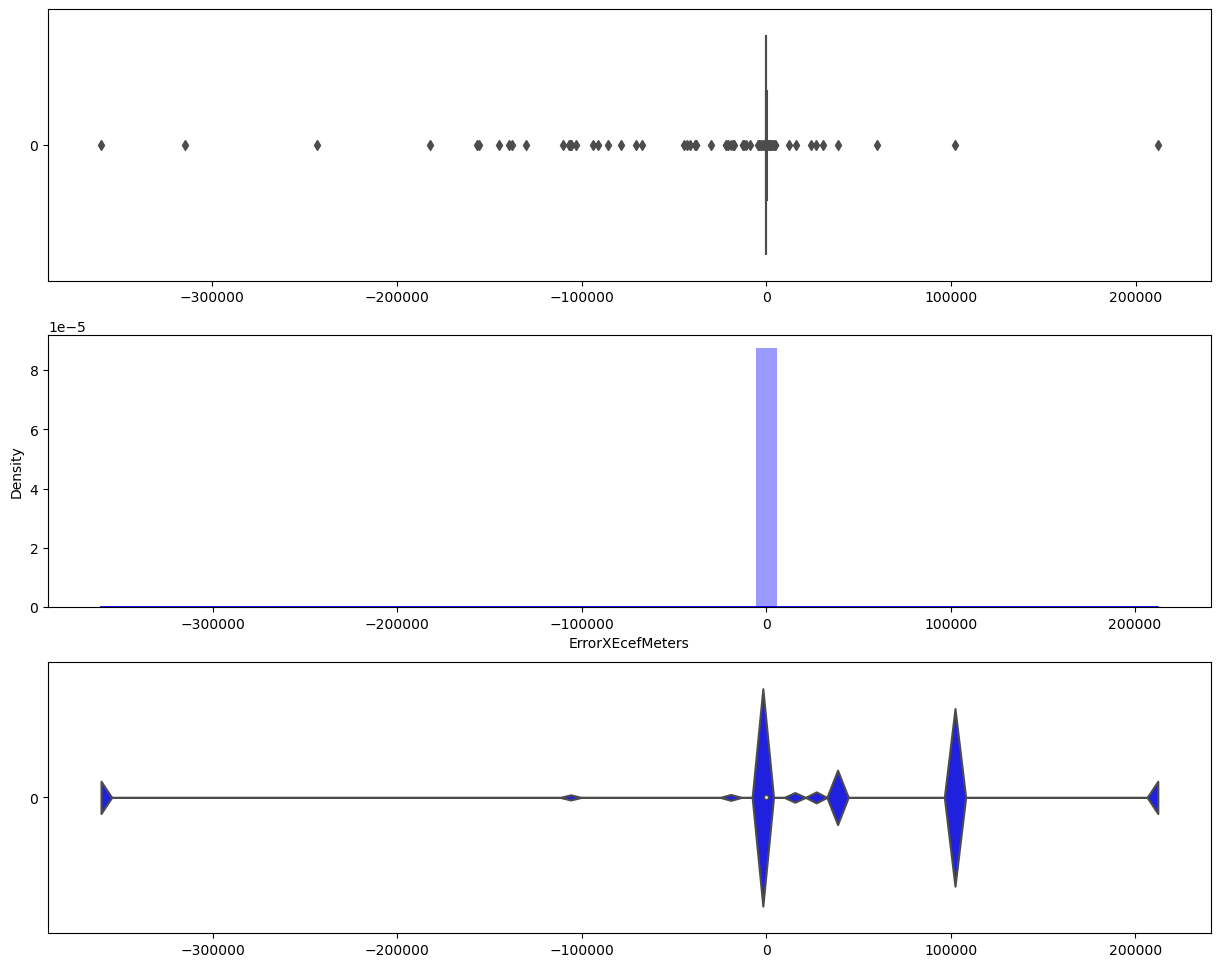

In [8]:
f, axes = plt.subplots(3, 1, figsize=(15,12))

# uni-variate visualisation for errorxecefmeters eda

errorxecefmeters_eda_uni = target_df["ErrorXEcefMeters"]
sb.boxplot(errorxecefmeters_eda_uni, orient = "h", color = "b", ax = axes[0]) # boxplot for ErrorXEcefMeters
sb.distplot(errorxecefmeters_eda_uni, kde = True, color = "b", ax = axes[1]) # distplot for ErrorXEcefMeters
sb.violinplot(errorxecefmeters_eda_uni, orient = "h", color = "b", ax = axes[2]) # violinplot for ErrorXEcefMeters

/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_12766/3381124806.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(erroryecefmeters_eda_uni, kde = True, color = "g", ax = axes[1]) # distplot for ErrorXEcefMeters


<Axes: >

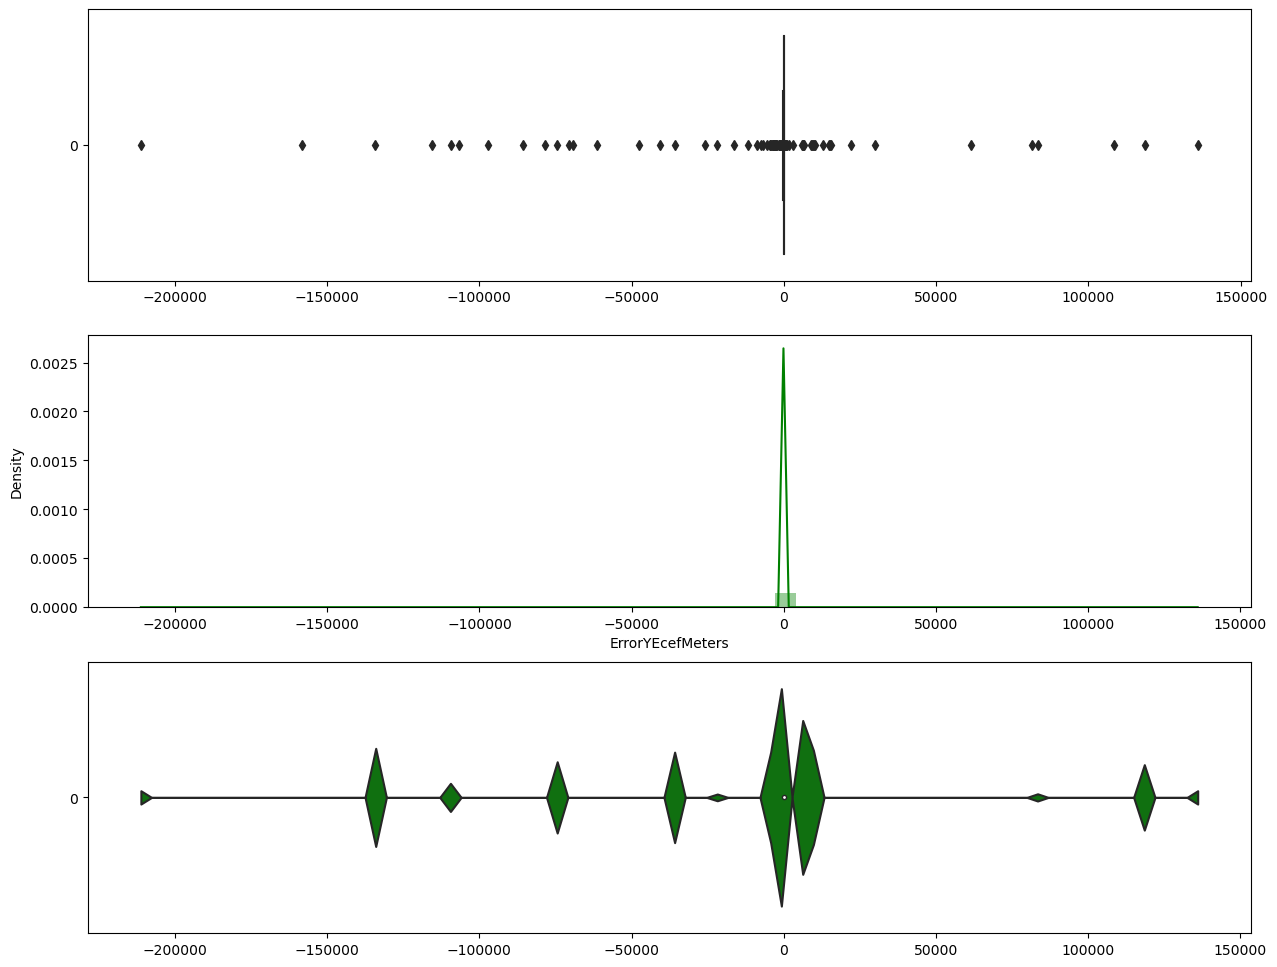

In [9]:
f, axes = plt.subplots(3, 1, figsize=(15,12))

# uni-variate visualisation for erroryecefmeters eda

erroryecefmeters_eda_uni = target_df["ErrorYEcefMeters"]
sb.boxplot(erroryecefmeters_eda_uni, orient = "h", color = "g", ax = axes[0]) # boxplot for ErrorXEcefMeters
sb.distplot(erroryecefmeters_eda_uni, kde = True, color = "g", ax = axes[1]) # distplot for ErrorXEcefMeters
sb.violinplot(erroryecefmeters_eda_uni, orient = "h", color = "g", ax = axes[2]) # violinplot for ErrorXEcefMeters

In [10]:
# 11734 outliers from ErrorXEcefMeters
# 18262 outliers from ErrorYEcefMeters
# 18390 outliers total

output_x = target_df['ErrorXEcefMeters']
output_y = target_df['ErrorYEcefMeters']

Q1x = output_x.quantile(0.25)
Q3x = output_x.quantile(0.75)
IQRx = Q3x - Q1x

Q1y = output_y.quantile(0.25)
Q3y = output_y.quantile(0.75)
IQRy = Q3y - Q1y

lower_boundx = Q1x - 1.5 * IQRx
upper_boundx = Q3x + 1.5 * IQRx

lower_boundy = Q1y - 1.5 * IQRy
upper_boundy = Q3y + 1.5 * IQRy

target_clean_df = target_df[(output_x >= lower_boundx) & (output_x <= upper_boundx)]
target_clean_df = target_clean_df[(output_y >= lower_boundy) & (output_y <= upper_boundy)]
print(target_clean_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 277210 entries, 0 to 295632
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   UnixTimeMillis          277210 non-null  int64  
 1   device                  277210 non-null  object 
 2   drive_id                277210 non-null  object 
 3   LatitudeDegrees         277210 non-null  float64
 4   LongitudeDegrees        277210 non-null  float64
 5   GroundTruthXEcefMeters  277210 non-null  float64
 6   GroundTruthYEcefMeters  277210 non-null  float64
 7   WlsPositionXEcefMeters  277210 non-null  float64
 8   WlsPositionYEcefMeters  277210 non-null  float64
 9   ErrorXEcefMeters        277210 non-null  float64
 10  ErrorYEcefMeters        277210 non-null  float64
dtypes: float64(8), int64(1), object(2)
memory usage: 25.4+ MB
None


/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_12766/864898753.py:23: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  target_clean_df = target_clean_df[(output_y >= lower_boundy) & (output_y <= upper_boundy)]


In [11]:
def get_cn0dbhz(df_gnss):
    cn0dbhz_grp_df = df_gnss.groupby(
        ['utcTimeMillis', 'drive_id', 'device'],
        as_index=False
    )[[
        'Cn0DbHz'
    ]].mean()
    
    return cn0dbhz_grp_df

def merge_target(merge_df, target_df):
    merge_renamed_df = merge_df.rename(columns={"utcTimeMillis": "UnixTimeMillis"})
    
    df_merge = merge_renamed_df.merge(target_df[['UnixTimeMillis', 'ErrorXEcefMeters', 'ErrorYEcefMeters', 'drive_id', 'device']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'inner')
    
    return df_merge


cn0dbhz_mean_df = get_cn0dbhz(gnss_df)
cn0dbhz_merge_df = merge_target(cn0dbhz_mean_df, target_clean_df)

print(cn0dbhz_mean_df)
print()
print(cn0dbhz_merge_df)

        utcTimeMillis             drive_id                 device    Cn0DbHz
0       1589573679445  2020-05-15-US-MTV-1         GooglePixel4XL  31.891304
1       1589573680445  2020-05-15-US-MTV-1         GooglePixel4XL  30.715385
2       1589573681445  2020-05-15-US-MTV-1         GooglePixel4XL  31.920000
3       1589573682445  2020-05-15-US-MTV-1         GooglePixel4XL  31.192593
4       1589573683445  2020-05-15-US-MTV-1         GooglePixel4XL  32.000000
...               ...                  ...                    ...        ...
295628  1640724243000  2021-12-28-US-MTV-1              XiaomiMi8  25.792816
295629  1640724243999  2021-12-28-US-MTV-1  SamsungGalaxyS20Ultra  28.406720
295630  1640724244000  2021-12-28-US-MTV-1              XiaomiMi8  25.816935
295631  1640724244999  2021-12-28-US-MTV-1  SamsungGalaxyS20Ultra  28.654278
295632  1640724245999  2021-12-28-US-MTV-1  SamsungGalaxyS20Ultra  28.551732

[295633 rows x 4 columns]

        UnixTimeMillis             drive_id     

/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_8433/3020855543.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(cn0dbhz_eda_uni, kde = True, color = "g", ax = axes[1]) # distplot for Cn0DbHz


<Axes: >

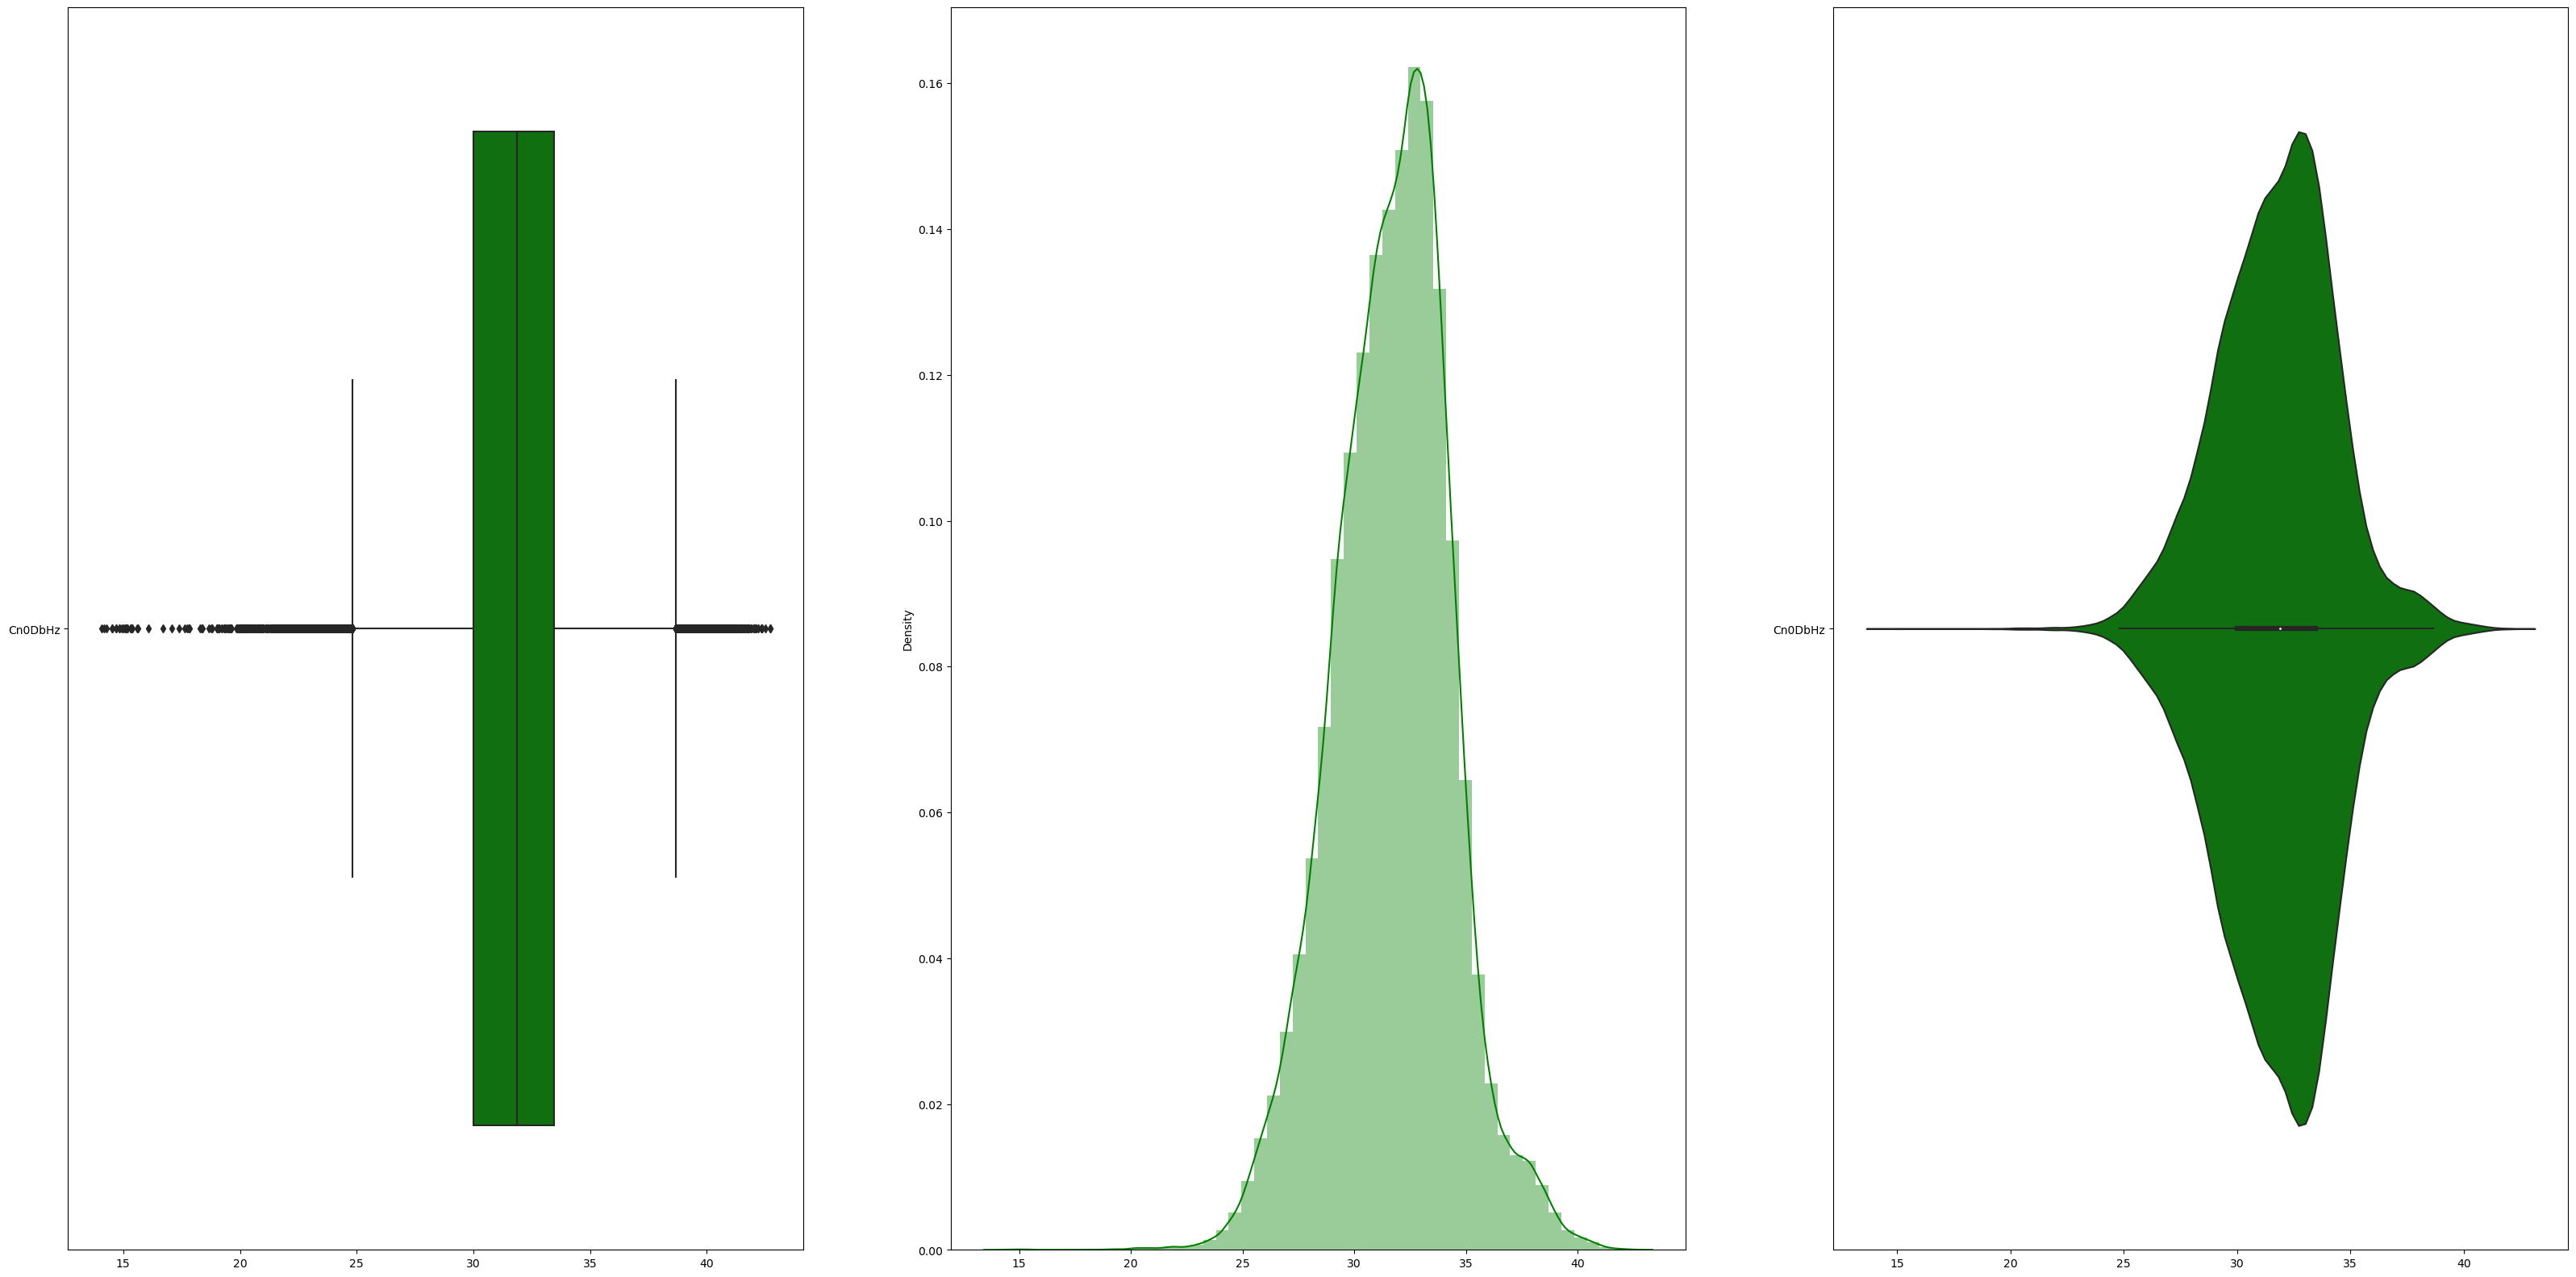

In [16]:
f, axes = plt.subplots(1, 3, figsize=(40,20))

# uni-variate visualisation for cn0dbhz eda

cn0dbhz_eda_uni = pd.DataFrame(cn0dbhz_merge_df[["Cn0DbHz"]])
sb.boxplot(cn0dbhz_eda_uni, orient = "h", color = "g", ax = axes[0]) # boxplot for Cn0DbHz
sb.distplot(cn0dbhz_eda_uni, kde = True, color = "g", ax = axes[1]) # distplot for Cn0DbHz
sb.violinplot(cn0dbhz_eda_uni, orient = "h", color = "g", ax = axes[2]) # violinplot for Cn0DbHz

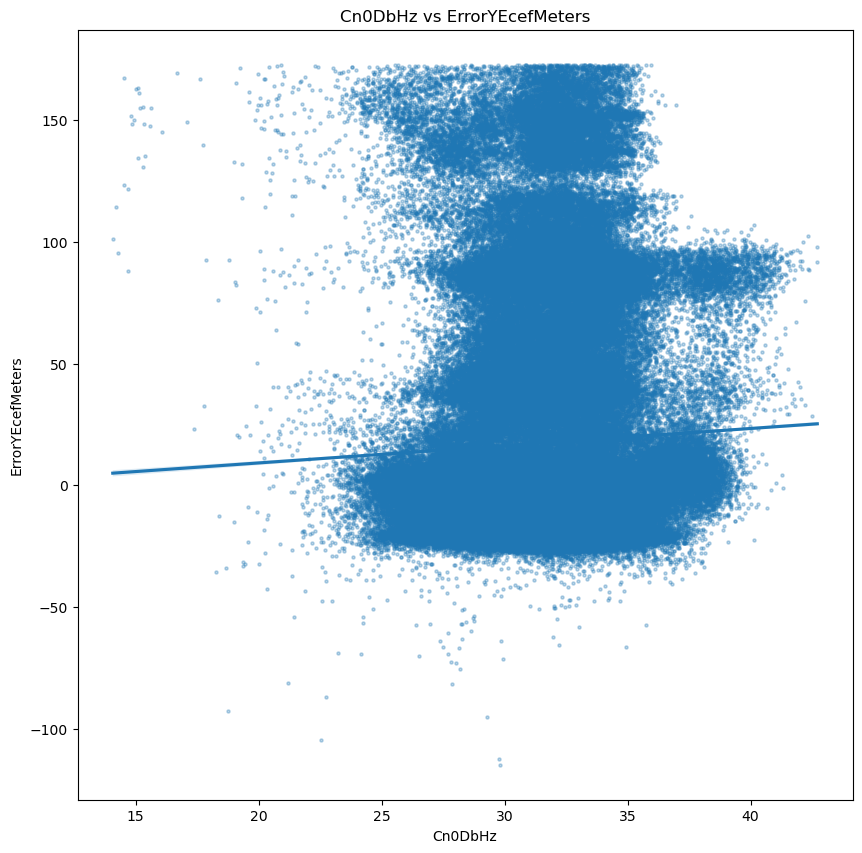

In [17]:
# scatterplot for Cn0DbHz vs ErrorYEcefMeters

plt.figure(figsize=(10, 10))
sb.regplot(x="Cn0DbHz", y="ErrorYEcefMeters", data=cn0dbhz_merge_df, scatter_kws={'alpha':0.3, 's':5})
plt.xlabel("Cn0DbHz")
plt.ylabel("ErrorYEcefMeters")
plt.title("Cn0DbHz vs ErrorYEcefMeters")
plt.show()

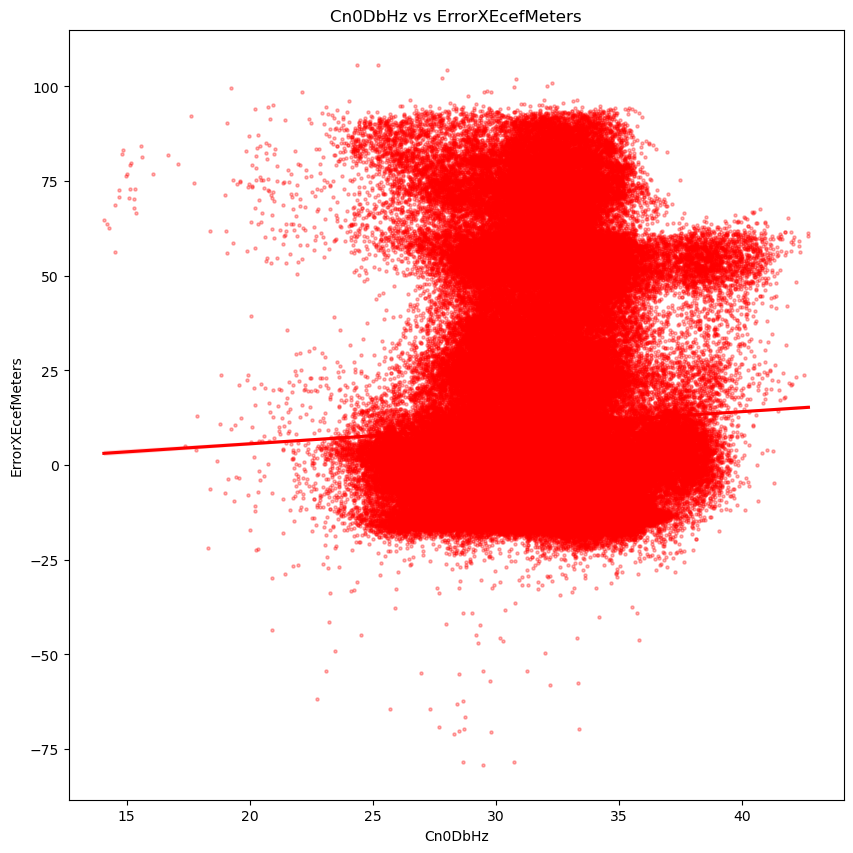

In [18]:
# scatterplot for Cn0DbHz vs ErrorYEcefMeters

plt.figure(figsize=(10, 10))
sb.regplot(x="Cn0DbHz", y="ErrorXEcefMeters", color='r', data=cn0dbhz_merge_df, scatter_kws={'alpha':0.3, 's':5})
plt.xlabel("Cn0DbHz")
plt.ylabel("ErrorXEcefMeters")
plt.title("Cn0DbHz vs ErrorXEcefMeters")
plt.show()

In [12]:
def get_multipathindicator(df_gnss):
    multipath_grp_df = df_gnss.groupby(
        ['utcTimeMillis', 'drive_id', 'device'],
        as_index=False
    )['MultipathIndicator'].agg(lambda x: x.value_counts().index[0])
    
    return multipath_grp_df

def merge_target(merge_df, target_df):
    merge_renamed_df = merge_df.rename(columns={"utcTimeMillis": "UnixTimeMillis"})
    
    df_merge = merge_renamed_df.merge(target_df[['UnixTimeMillis', 'ErrorXEcefMeters', 'ErrorYEcefMeters', 'drive_id', 'device']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'inner')
    
    return df_merge


multipath_grp_df = get_multipathindicator(gnss_df)
multipath_merge_df = merge_target(multipath_grp_df, target_clean_df)

print(multipath_grp_df)
print()
print(multipath_merge_df)

        utcTimeMillis             drive_id                 device  \
0       1589573679445  2020-05-15-US-MTV-1         GooglePixel4XL   
1       1589573680445  2020-05-15-US-MTV-1         GooglePixel4XL   
2       1589573681445  2020-05-15-US-MTV-1         GooglePixel4XL   
3       1589573682445  2020-05-15-US-MTV-1         GooglePixel4XL   
4       1589573683445  2020-05-15-US-MTV-1         GooglePixel4XL   
...               ...                  ...                    ...   
295628  1640724243000  2021-12-28-US-MTV-1              XiaomiMi8   
295629  1640724243999  2021-12-28-US-MTV-1  SamsungGalaxyS20Ultra   
295630  1640724244000  2021-12-28-US-MTV-1              XiaomiMi8   
295631  1640724244999  2021-12-28-US-MTV-1  SamsungGalaxyS20Ultra   
295632  1640724245999  2021-12-28-US-MTV-1  SamsungGalaxyS20Ultra   

        MultipathIndicator  
0                        0  
1                        0  
2                        0  
3                        0  
4                        0

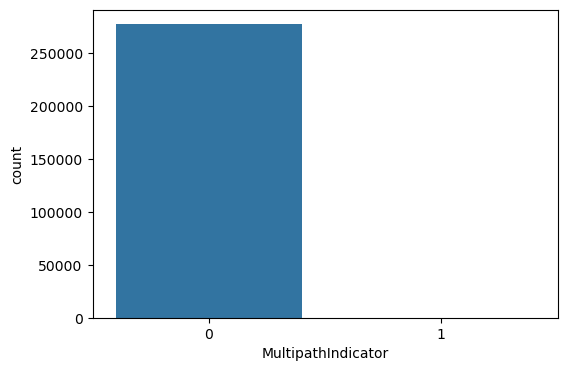

In [20]:
plt.figure(figsize=(6,4))
sb.countplot(x="MultipathIndicator", data=multipath_merge_df)
plt.show()

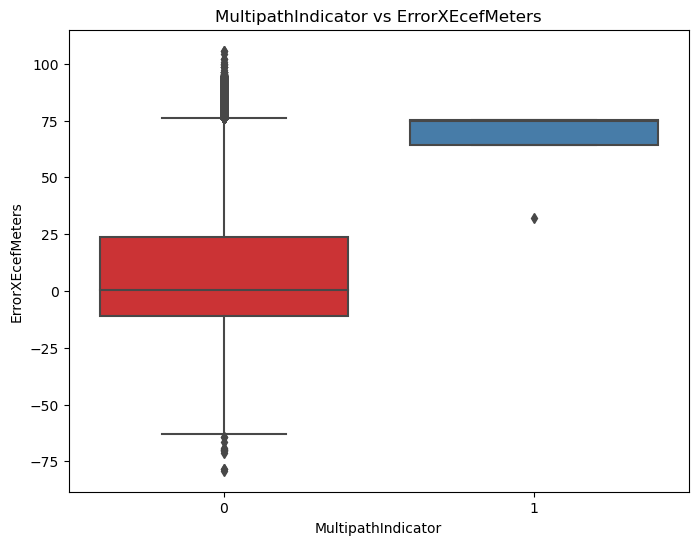

In [21]:
plt.figure(figsize=(8,6))
sb.boxplot(x="MultipathIndicator", y="ErrorXEcefMeters", data=multipath_merge_df, palette='Set1')
plt.title("MultipathIndicator vs ErrorXEcefMeters")
plt.show()

In [22]:
print(multipath_merge_df['MultipathIndicator'].value_counts())

MultipathIndicator
0    277206
1         4
Name: count, dtype: int64


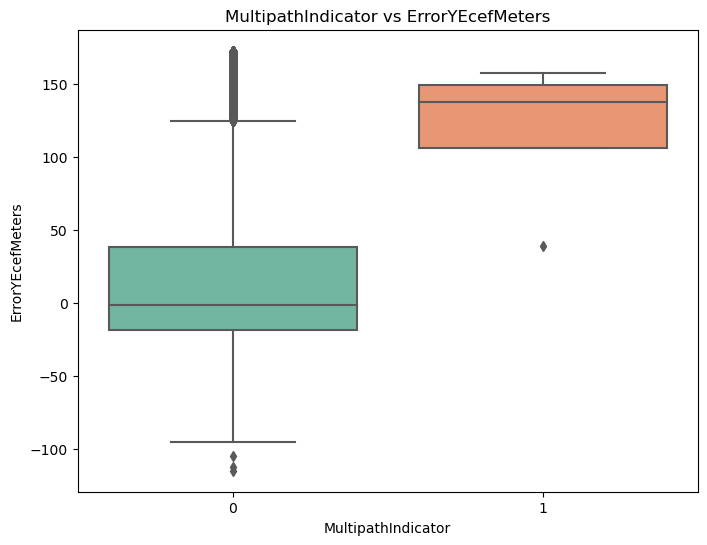

In [23]:
plt.figure(figsize=(8,6))
sb.boxplot(x="MultipathIndicator", y="ErrorYEcefMeters", data=multipath_merge_df, palette='Set2')
plt.title("MultipathIndicator vs ErrorYEcefMeters")
plt.show()
print()

In [13]:
def get_satcount(df_gnss):
    satcount_grp_df = df_gnss.groupby(['utcTimeMillis', 'device', 'drive_id'], as_index=False)['Svid'].count()
    
    satcount_grp_df = satcount_grp_df.rename(columns={'Svid': 'SatCount'})
    return satcount_grp_df

def merge_target(merge_df, target_df):
    merge_renamed_df = merge_df.rename(columns={"utcTimeMillis": "UnixTimeMillis"})
    
    df_merge = merge_renamed_df.merge(target_df[['UnixTimeMillis', 'ErrorXEcefMeters', 'ErrorYEcefMeters', 'drive_id', 'device']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'inner')
    
    return df_merge


satcount_grp_df = get_satcount(gnss_df)
satcount_merge_df = merge_target(satcount_grp_df, target_clean_df)

print(satcount_grp_df)
print()
print(satcount_merge_df)

        utcTimeMillis                 device             drive_id  SatCount
0       1589573679445         GooglePixel4XL  2020-05-15-US-MTV-1        23
1       1589573680445         GooglePixel4XL  2020-05-15-US-MTV-1        26
2       1589573681445         GooglePixel4XL  2020-05-15-US-MTV-1        25
3       1589573682445         GooglePixel4XL  2020-05-15-US-MTV-1        27
4       1589573683445         GooglePixel4XL  2020-05-15-US-MTV-1        26
...               ...                    ...                  ...       ...
295628  1640724243000              XiaomiMi8  2021-12-28-US-MTV-1        42
295629  1640724243999  SamsungGalaxyS20Ultra  2021-12-28-US-MTV-1        37
295630  1640724244000              XiaomiMi8  2021-12-28-US-MTV-1        42
295631  1640724244999  SamsungGalaxyS20Ultra  2021-12-28-US-MTV-1        37
295632  1640724245999  SamsungGalaxyS20Ultra  2021-12-28-US-MTV-1        37

[295633 rows x 4 columns]

        UnixTimeMillis                 device             dr

/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_8433/2578798417.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(satcount_eda_uni, kde = True, color = "g", ax = axes[1]) # distplot for SatCount


<Axes: >

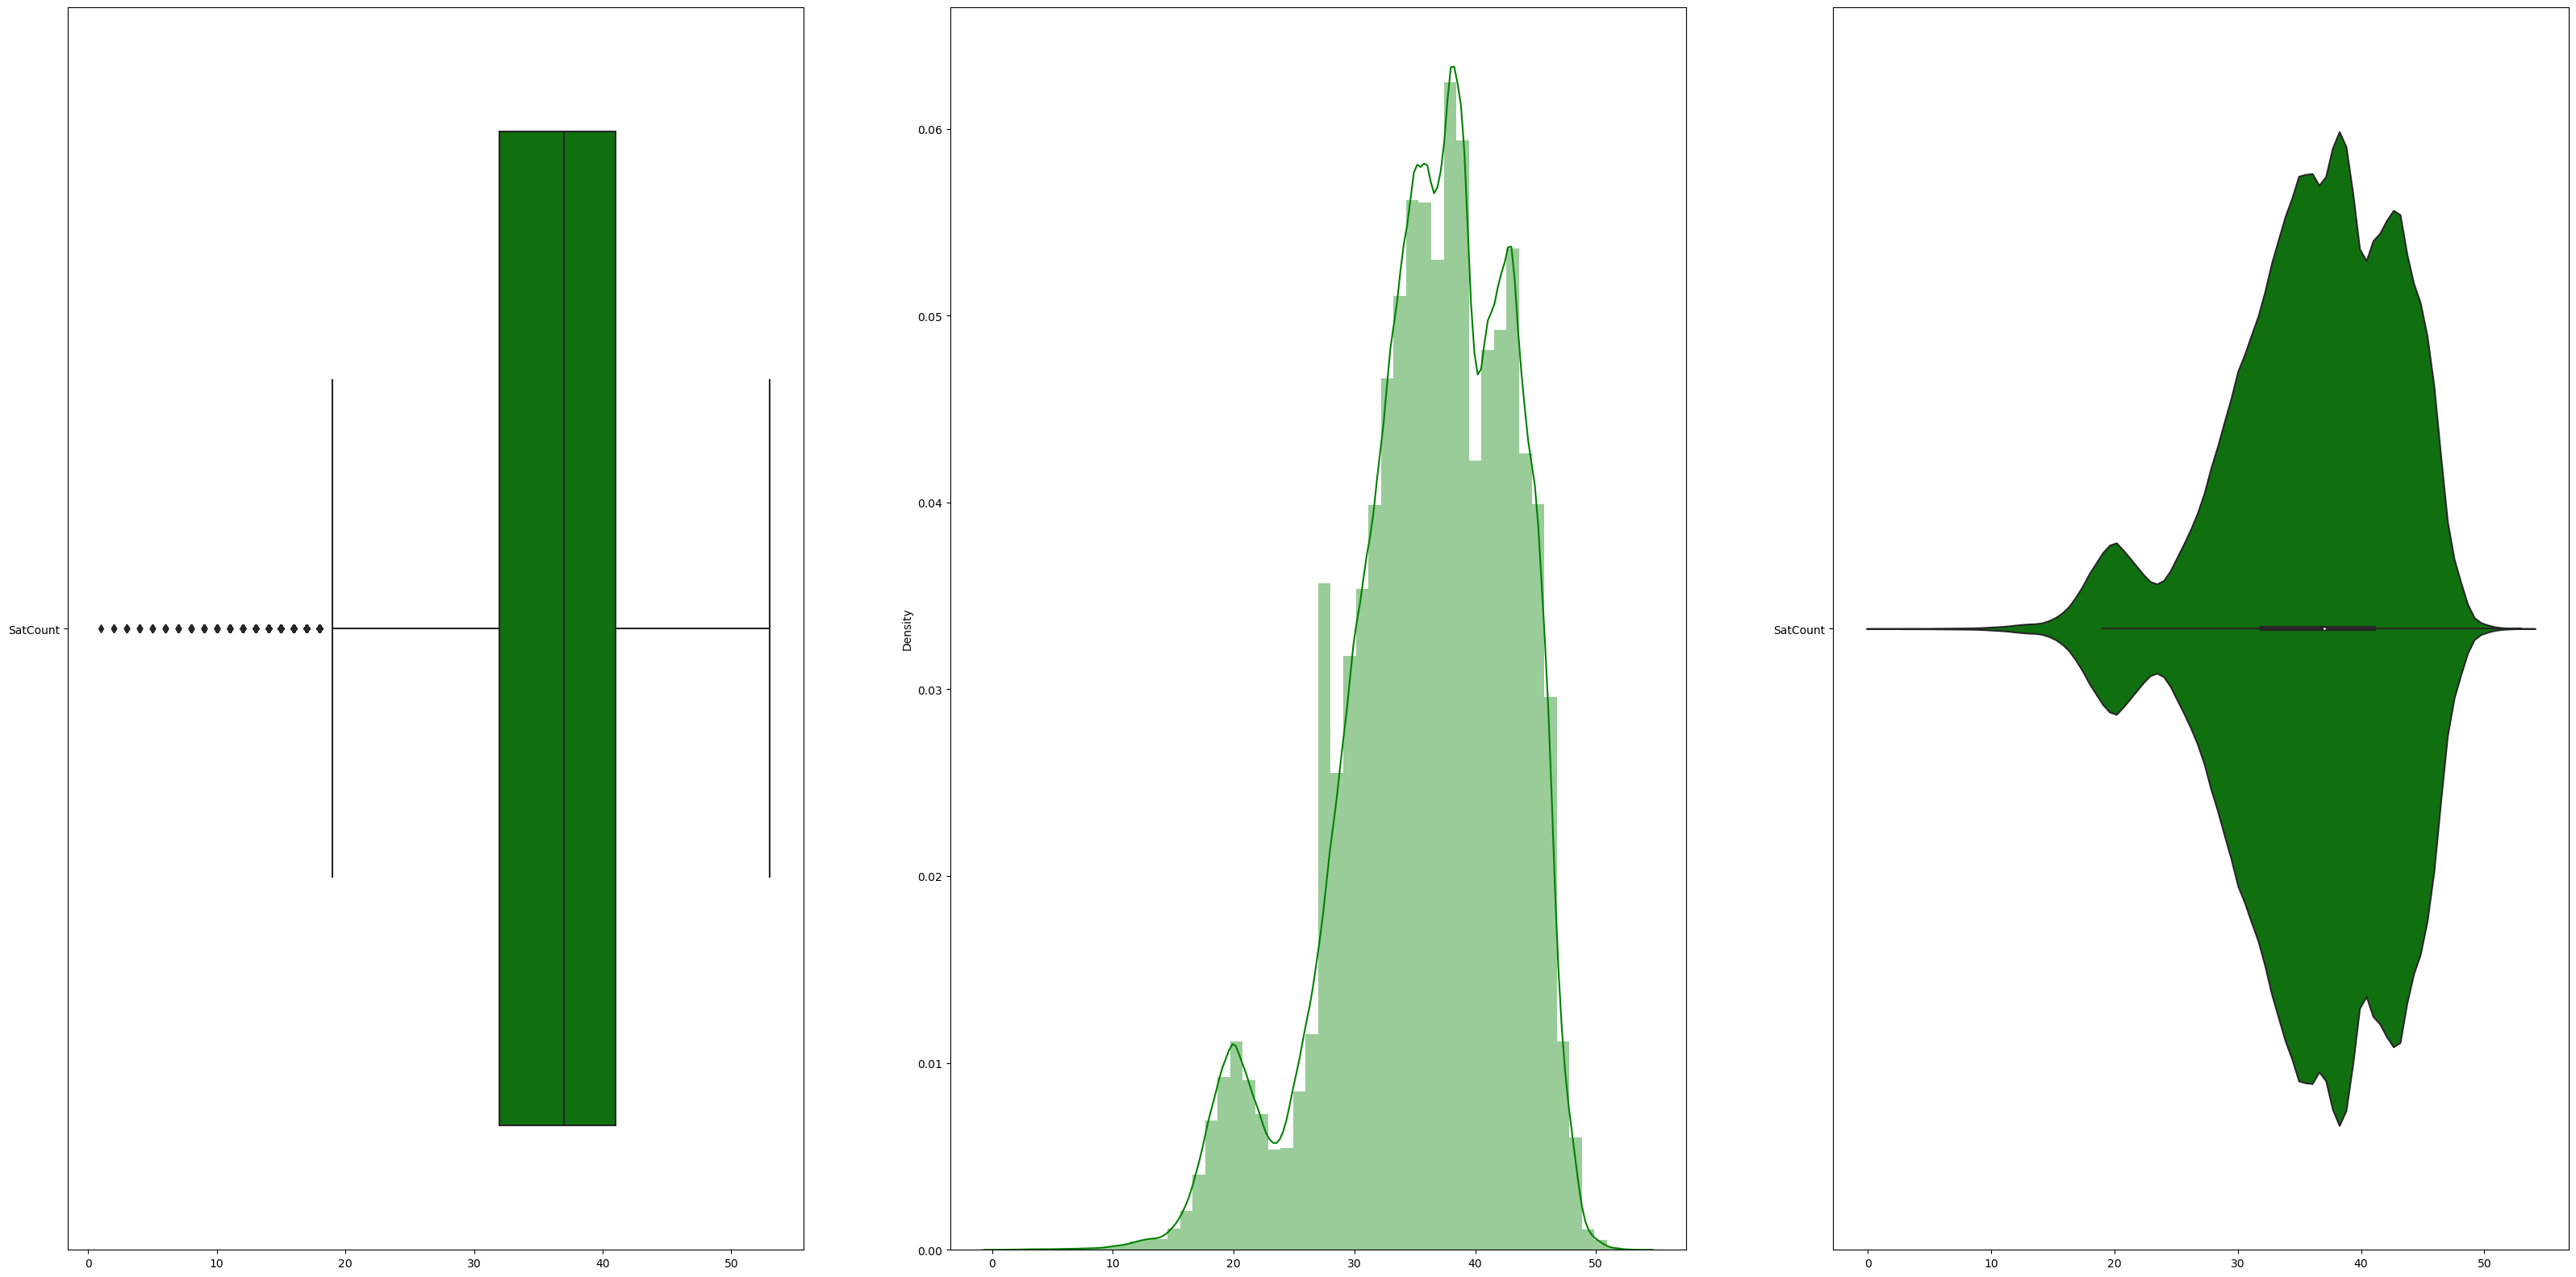

In [25]:
f, axes = plt.subplots(1, 3, figsize=(40,20))

# uni-variate visualisation for SatCount eda

satcount_eda_uni = pd.DataFrame(satcount_merge_df[["SatCount"]])
sb.boxplot(satcount_eda_uni, orient = "h", color = "g", ax = axes[0]) # boxplot for SatCount
sb.distplot(satcount_eda_uni, kde = True, color = "g", ax = axes[1]) # distplot for SatCount
sb.violinplot(satcount_eda_uni, orient = "h", color = "g", ax = axes[2]) # violinplot for SatCount

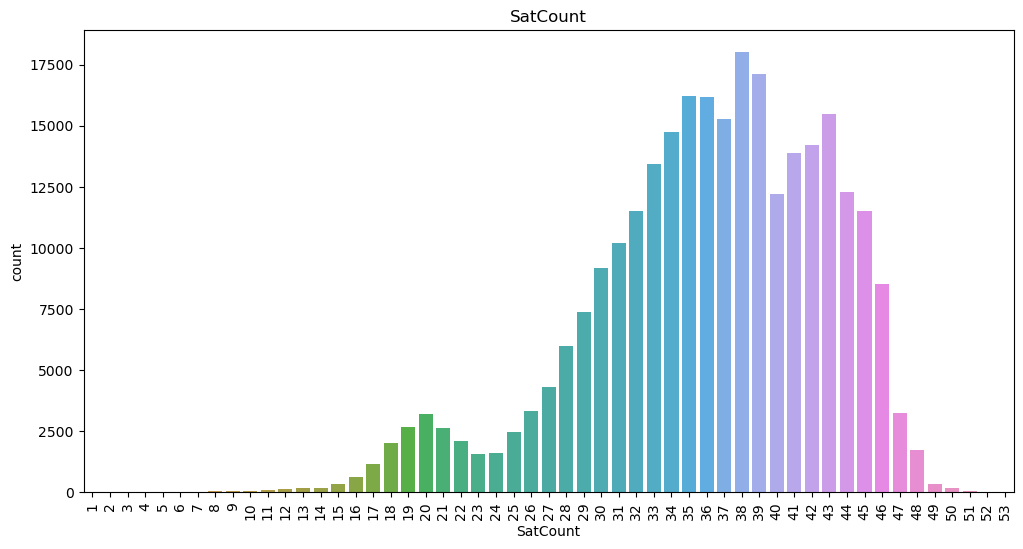

In [26]:
# scatterplot for SatCount vs ErrorXEcefMeters

plt.figure(figsize=(12,6))
sb.countplot(x="SatCount", data=satcount_merge_df)
plt.xticks(rotation=90)
plt.title("SatCount")
plt.show()

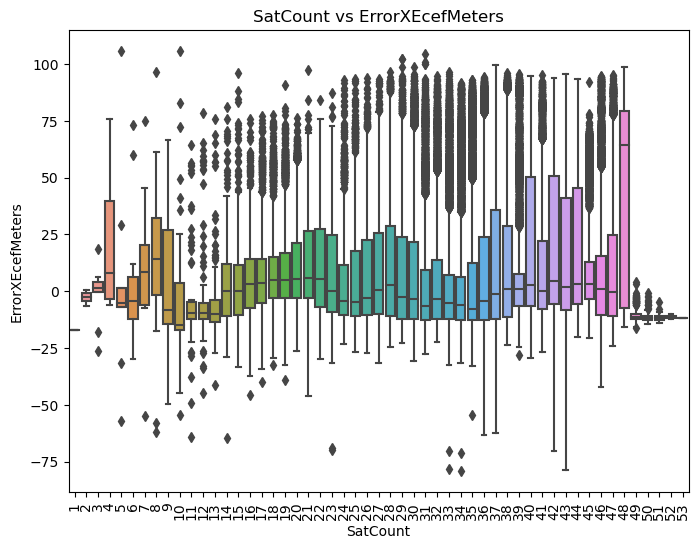

In [27]:
plt.figure(figsize=(8,6))
sb.boxplot(x="SatCount", y="ErrorXEcefMeters", data=satcount_merge_df)
plt.title("SatCount vs ErrorXEcefMeters")
plt.xticks(rotation=90)
plt.show()
print()

In [14]:
def get_elevationdeg(df_gnss):
    elevationdeg_grp_df = df_gnss.groupby(
        ['utcTimeMillis', 'drive_id', 'device'],
        as_index=False
    )[[
        'SvElevationDegrees'
    ]].mean()
    
    return elevationdeg_grp_df

def merge_target(merge_df, target_df):
    merge_renamed_df = merge_df.rename(columns={"utcTimeMillis": "UnixTimeMillis"})
    
    df_merge = merge_renamed_df.merge(target_df[['UnixTimeMillis', 'ErrorXEcefMeters', 'ErrorYEcefMeters', 'drive_id', 'device']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'inner')
    
    return df_merge


elevationdeg_mean_df = get_elevationdeg(gnss_df)
elevationdeg_merge_df = merge_target(elevationdeg_mean_df, target_clean_df)

print(elevationdeg_mean_df)
print()
print(elevationdeg_merge_df)

        utcTimeMillis             drive_id                 device  \
0       1589573679445  2020-05-15-US-MTV-1         GooglePixel4XL   
1       1589573680445  2020-05-15-US-MTV-1         GooglePixel4XL   
2       1589573681445  2020-05-15-US-MTV-1         GooglePixel4XL   
3       1589573682445  2020-05-15-US-MTV-1         GooglePixel4XL   
4       1589573683445  2020-05-15-US-MTV-1         GooglePixel4XL   
...               ...                  ...                    ...   
295628  1640724243000  2021-12-28-US-MTV-1              XiaomiMi8   
295629  1640724243999  2021-12-28-US-MTV-1  SamsungGalaxyS20Ultra   
295630  1640724244000  2021-12-28-US-MTV-1              XiaomiMi8   
295631  1640724244999  2021-12-28-US-MTV-1  SamsungGalaxyS20Ultra   
295632  1640724245999  2021-12-28-US-MTV-1  SamsungGalaxyS20Ultra   

        SvElevationDegrees  
0                48.647436  
1                43.490434  
2                45.050207  
3                43.633448  
4                45.138635

/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_8433/3397424205.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(elevationdeg_eda_uni, kde = True, color = "g", ax = axes[1]) # distplot for SatCount


<Axes: >

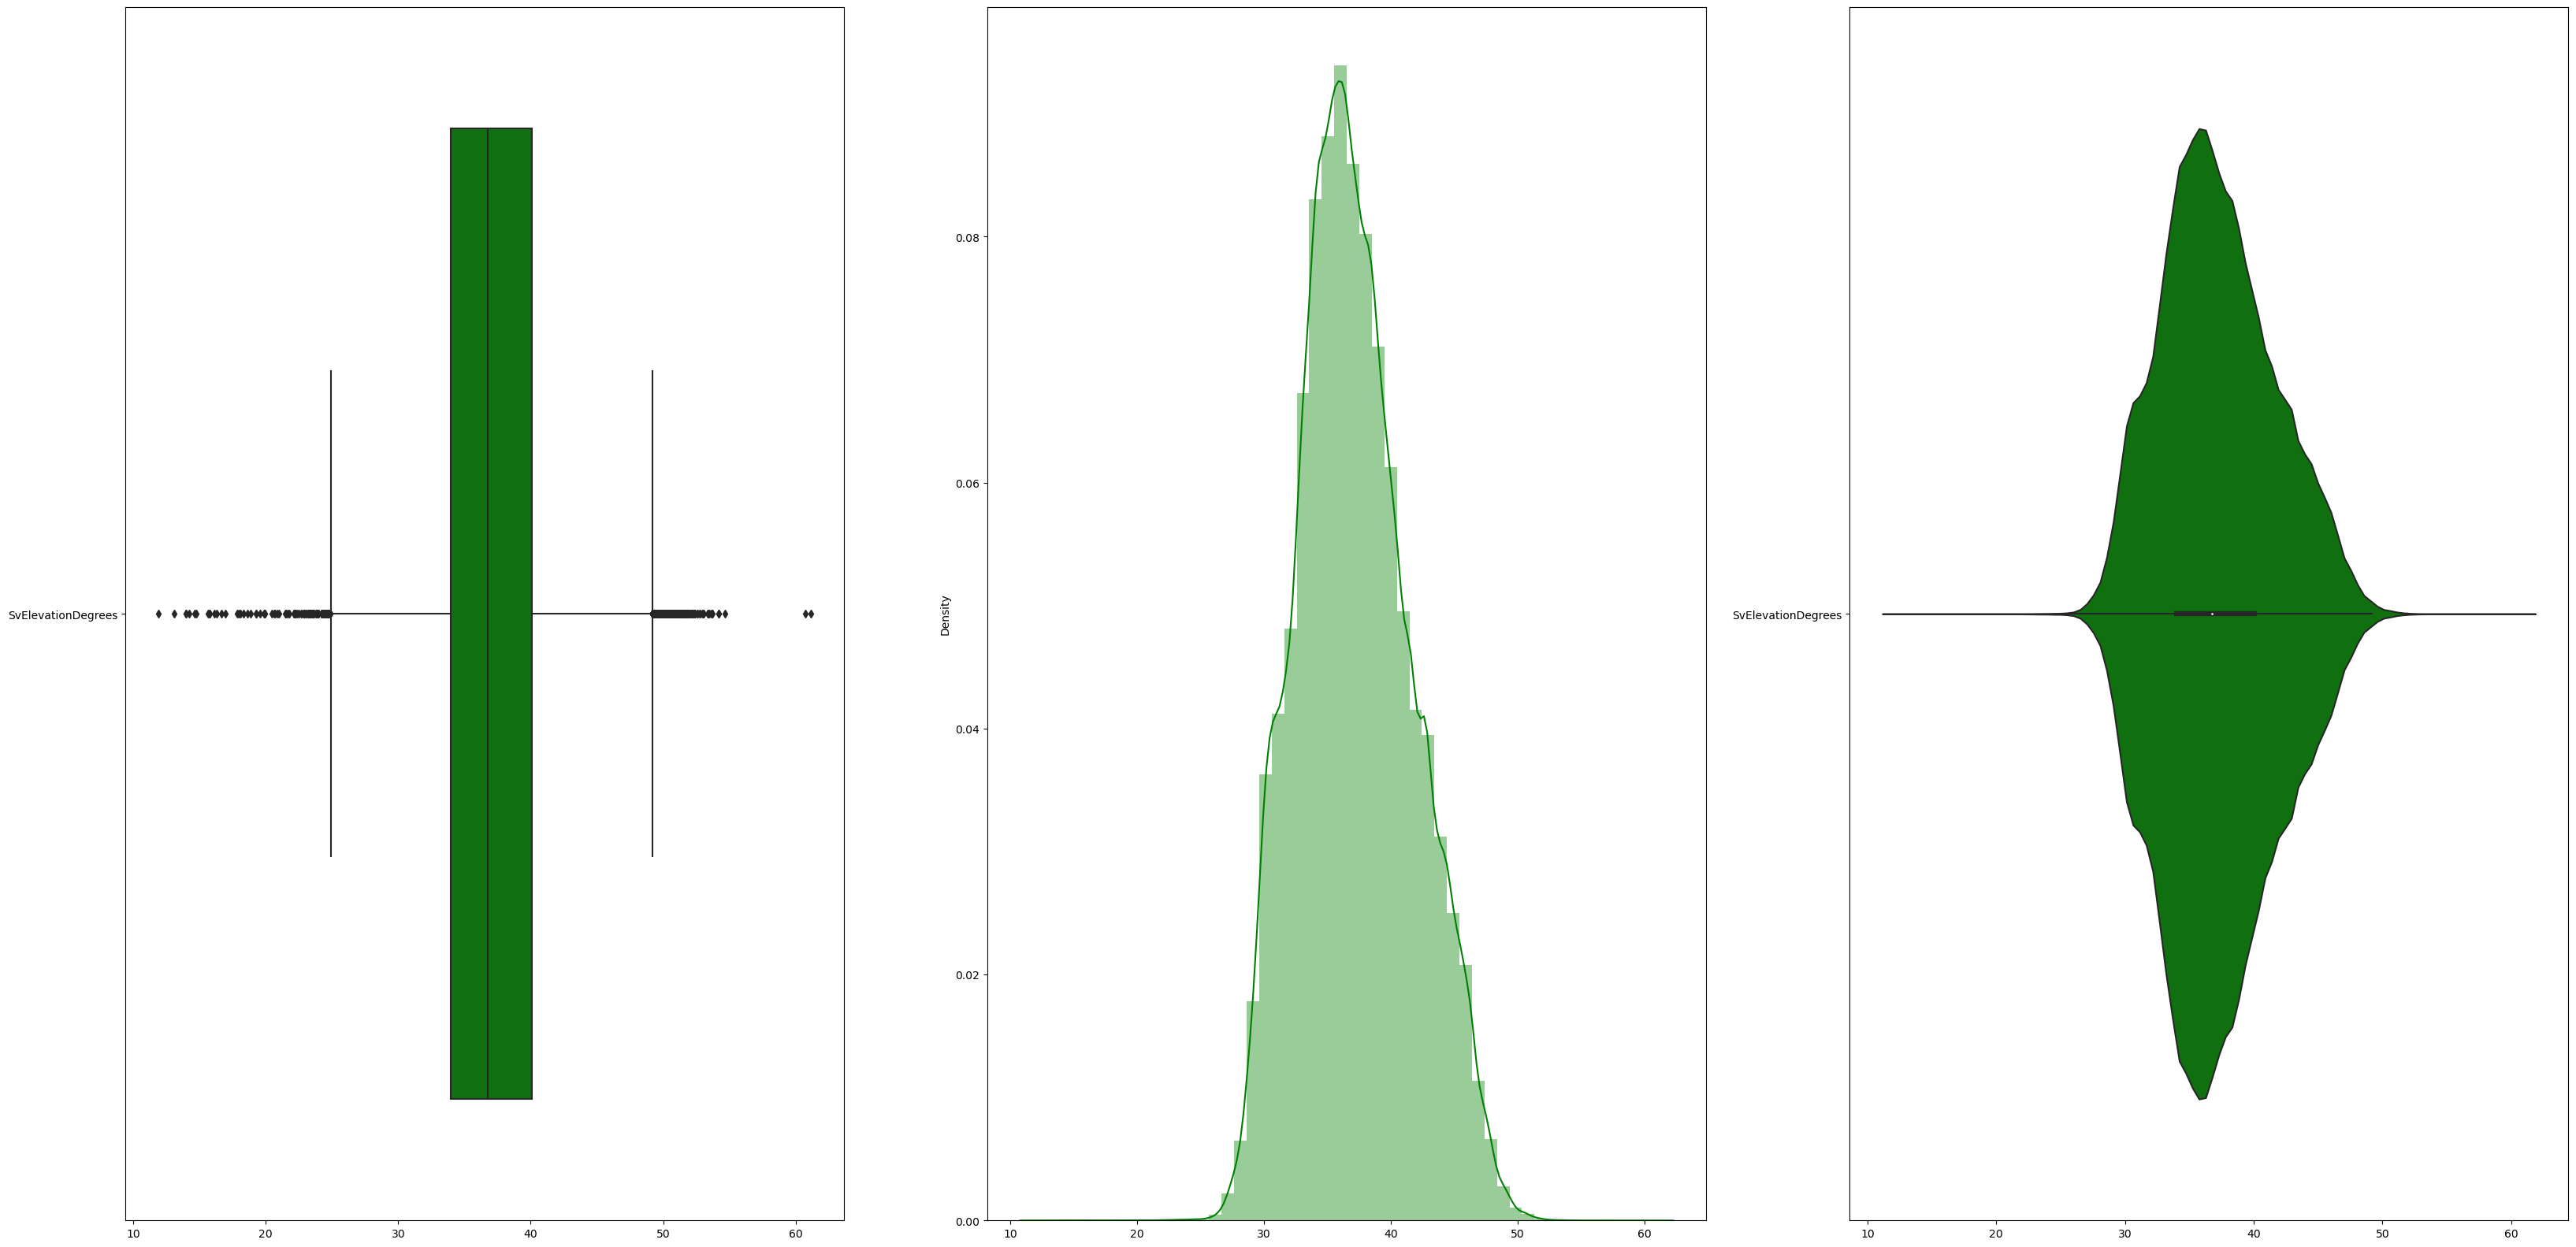

In [29]:
f, axes = plt.subplots(1, 3, figsize=(40,20))

# uni-variate visualisation for SvElevationDegrees eda

elevationdeg_eda_uni = pd.DataFrame(elevationdeg_merge_df[["SvElevationDegrees"]])
sb.boxplot(elevationdeg_eda_uni, orient = "h", color = "g", ax = axes[0]) # boxplot for SatCount
sb.distplot(elevationdeg_eda_uni, kde = True, color = "g", ax = axes[1]) # distplot for SatCount
sb.violinplot(elevationdeg_eda_uni, orient = "h", color = "g", ax = axes[2]) # violinplot for SatCount

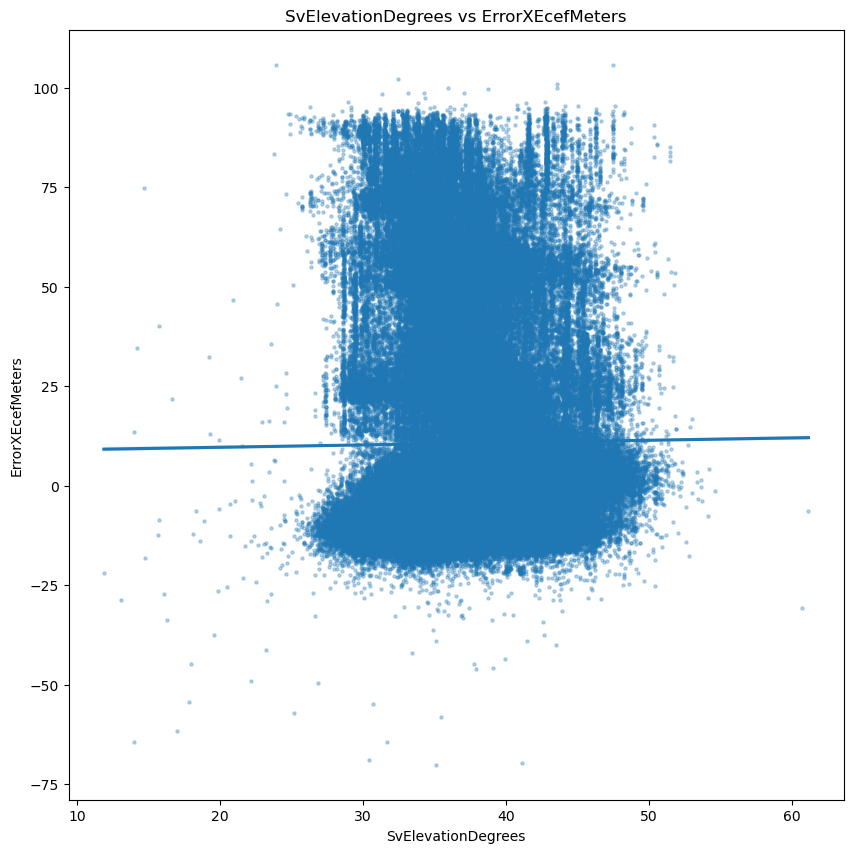

In [30]:
# scatterplot for Cn0DbHz vs ErrorYEcefMeters

plt.figure(figsize=(10, 10))
sb.regplot(x="SvElevationDegrees", y="ErrorXEcefMeters", data=elevationdeg_merge_df, scatter_kws={'alpha':0.3, 's':5})
plt.xlabel("SvElevationDegrees")
plt.ylabel("ErrorXEcefMeters")
plt.title("SvElevationDegrees vs ErrorXEcefMeters")
plt.show()

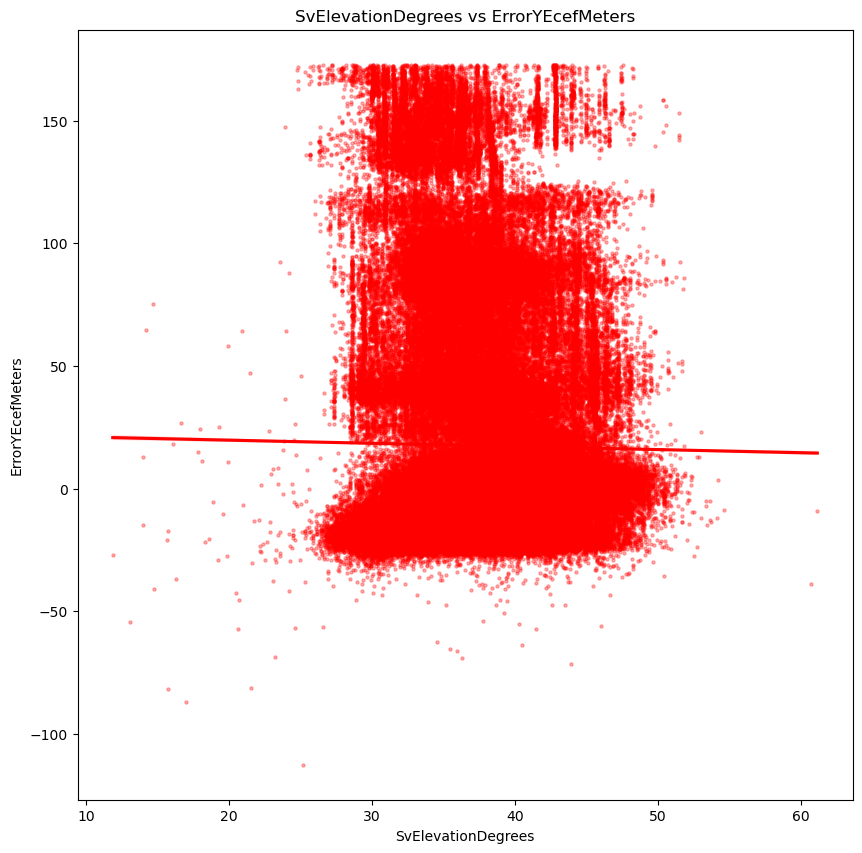

In [31]:
# scatterplot for Cn0DbHz vs ErrorYEcefMeters

plt.figure(figsize=(10, 10))
sb.regplot(x="SvElevationDegrees", y="ErrorYEcefMeters", color='r', data=elevationdeg_merge_df, scatter_kws={'alpha':0.3, 's':5})
plt.xlabel("SvElevationDegrees")
plt.ylabel("ErrorYEcefMeters")
plt.title("SvElevationDegrees vs ErrorYEcefMeters")
plt.show()

In [32]:
'''
parent_folder = "../train"

# retrieve device.imu files from train
imu_files = glob.glob(os.path.join(parent_folder, "*", "*", "device_imu.csv"))
print(imu_files) 
'''

'\nparent_folder = "../train"\n\n# retrieve device.imu files from train\nimu_files = glob.glob(os.path.join(parent_folder, "*", "*", "device_imu.csv"))\nprint(imu_files) \n'

In [33]:
'''
imu_list = []

for file in imu_files:
    imu_file = pd.read_csv(file)
    parts = file.split(os.sep) # eg ['train', '2021-12-28-US-MTV-1', 'GooglePixel5', 'device_imu.csv']
    imu_file["drive_id"] = parts[-3] 
    imu_file["device"] = parts[-2]
    imu_list.append(imu_file)

# combine all
imu_df = pd.concat(imu_list, ignore_index=True)
print(imu_df.head())
print()
'''

'\nimu_list = []\n\nfor file in imu_files:\n    imu_file = pd.read_csv(file)\n    parts = file.split(os.sep) # eg [\'train\', \'2021-12-28-US-MTV-1\', \'GooglePixel5\', \'device_imu.csv\']\n    imu_file["drive_id"] = parts[-3] \n    imu_file["device"] = parts[-2]\n    imu_list.append(imu_file)\n\n# combine all\nimu_df = pd.concat(imu_list, ignore_index=True)\nprint(imu_df.head())\nprint()\n'

In [15]:
%store -r imu_acc_df

print(imu_acc_df.head())
print(imu_acc_df.info())

    utcTimeMillis  MeasurementX  MeasurementY  MeasurementZ  \
0   1609800004434     -0.106481      9.829117     -0.751346   
3   1609800004444     -0.122632      9.720842     -0.784846   
5   1609800004454     -0.094516      9.762716     -0.770489   
8   1609800004464     -0.092124      9.819546     -0.760918   
10  1609800004474     -0.101097      9.762716     -0.765703   

               drive_id        device  
0   2021-01-04-US-SFO-2  GooglePixel5  
3   2021-01-04-US-SFO-2  GooglePixel5  
5   2021-01-04-US-SFO-2  GooglePixel5  
8   2021-01-04-US-SFO-2  GooglePixel5  
10  2021-01-04-US-SFO-2  GooglePixel5  
<class 'pandas.core.frame.DataFrame'>
Index: 18591313 entries, 0 to 56300259
Data columns (total 6 columns):
 #   Column         Dtype  
---  ------         -----  
 0   utcTimeMillis  int64  
 1   MeasurementX   float64
 2   MeasurementY   float64
 3   MeasurementZ   float64
 4   drive_id       object 
 5   device         object 
dtypes: float64(3), int64(1), object(2)
memory u

In [16]:
def get_accmag(merge_df):
    merge_df['AccMag'] = np.sqrt(merge_df['MeasurementX']**2 + merge_df['MeasurementY']**2 + merge_df['MeasurementZ']**2)
    
    return merge_df

def merge_target(merge_df, target_df):
    df_gt = target_df.sort_values('UnixTimeMillis')
    df_acc = merge_df.sort_values('utcTimeMillis')
    df_acc = df_acc.rename(columns={"utcTimeMillis": "UnixTimeMillis"})

    final_df = pd.merge_asof(
        df_gt, 
        df_acc, 
        on='UnixTimeMillis', 
        by=['drive_id', 'device'], 
        direction='nearest',
        tolerance=50 
    )
    
    return final_df

acc_merge_df = merge_target(imu_acc_df, target_clean_df)
acc_merge_df = get_accmag(acc_merge_df)
accmag_merge_df = acc_merge_df[['device', 'drive_id', 'UnixTimeMillis', 'ErrorXEcefMeters', 'ErrorYEcefMeters', 'AccMag']]
print(accmag_merge_df)

                       device             drive_id  UnixTimeMillis  \
0              GooglePixel4XL  2020-05-15-US-MTV-1   1589573679445   
1              GooglePixel4XL  2020-05-15-US-MTV-1   1589573680445   
2              GooglePixel4XL  2020-05-15-US-MTV-1   1589573681445   
3              GooglePixel4XL  2020-05-15-US-MTV-1   1589573682445   
4              GooglePixel4XL  2020-05-15-US-MTV-1   1589573683445   
...                       ...                  ...             ...   
277205              XiaomiMi8  2021-12-28-US-MTV-1   1640724243000   
277206  SamsungGalaxyS20Ultra  2021-12-28-US-MTV-1   1640724243999   
277207              XiaomiMi8  2021-12-28-US-MTV-1   1640724244000   
277208  SamsungGalaxyS20Ultra  2021-12-28-US-MTV-1   1640724244999   
277209  SamsungGalaxyS20Ultra  2021-12-28-US-MTV-1   1640724245999   

        ErrorXEcefMeters  ErrorYEcefMeters     AccMag  
0             -18.813320        -21.360899   9.423617  
1             -12.736810        -19.303595  10.

In [17]:
%store -r imu_gyro_df

# imu_gyro_df = imu_df[imu_df["MessageType"] == "UncalGyro"][["utcTimeMillis", "MeasurementX", "MeasurementY", "MeasurementZ", "drive_id", "device"]]

print(imu_gyro_df)

          utcTimeMillis  MeasurementX  MeasurementY  MeasurementZ  \
2         1609800004444     -0.004123      0.000305     -0.000611   
7         1609800004464      0.001680      0.000000     -0.000916   
12        1609800004484     -0.001374      0.000305      0.000611   
17        1609800004504      0.000153     -0.000611     -0.000916   
22        1609800004523     -0.001374      0.000611      0.001833   
...                 ...           ...           ...           ...   
56300244  1596756054342     -0.007504     -0.047186      0.018690   
56300248  1596756054362      0.020458     -0.020005      0.017495   
56300252  1596756054381      0.015344      0.020418     -0.030256   
56300256  1596756054400      0.028184      0.054607      0.007475   
56300260  1596756054420     -0.009692      0.038078     -0.037961   

                     drive_id          device  
2         2021-01-04-US-SFO-2    GooglePixel5  
7         2021-01-04-US-SFO-2    GooglePixel5  
12        2021-01-04-US-SFO

In [18]:
def get_gyromag(merge_df):
    merge_df['GyroMag'] = np.sqrt(merge_df['MeasurementX']**2 + merge_df['MeasurementY']**2 + merge_df['MeasurementZ']**2)
    
    return merge_df

def merge_target(merge_df, target_df):
    df_gt = target_df.sort_values('UnixTimeMillis')
    df_gyro = merge_df.sort_values('utcTimeMillis')
    df_gyro = df_gyro.rename(columns={"utcTimeMillis": "UnixTimeMillis"})

    final_df = pd.merge_asof(
        df_gt, 
        df_gyro, 
        on='UnixTimeMillis', 
        by=['drive_id', 'device'], 
        direction='nearest',
        tolerance=50 
    )
    
    return final_df

gyro_merge_df = merge_target(imu_gyro_df, target_clean_df)
gyro_merge_df = get_gyromag(gyro_merge_df)
gyromag_merge_df = gyro_merge_df[['device', 'drive_id', 'UnixTimeMillis', 'ErrorXEcefMeters', 'ErrorYEcefMeters', 'GyroMag']]
print(gyromag_merge_df)

                       device             drive_id  UnixTimeMillis  \
0              GooglePixel4XL  2020-05-15-US-MTV-1   1589573679445   
1              GooglePixel4XL  2020-05-15-US-MTV-1   1589573680445   
2              GooglePixel4XL  2020-05-15-US-MTV-1   1589573681445   
3              GooglePixel4XL  2020-05-15-US-MTV-1   1589573682445   
4              GooglePixel4XL  2020-05-15-US-MTV-1   1589573683445   
...                       ...                  ...             ...   
277205              XiaomiMi8  2021-12-28-US-MTV-1   1640724243000   
277206  SamsungGalaxyS20Ultra  2021-12-28-US-MTV-1   1640724243999   
277207              XiaomiMi8  2021-12-28-US-MTV-1   1640724244000   
277208  SamsungGalaxyS20Ultra  2021-12-28-US-MTV-1   1640724244999   
277209  SamsungGalaxyS20Ultra  2021-12-28-US-MTV-1   1640724245999   

        ErrorXEcefMeters  ErrorYEcefMeters   GyroMag  
0             -18.813320        -21.360899  0.026868  
1             -12.736810        -19.303595  0.026

In [19]:
del imu_acc_df
del imu_gyro_df
del gnss_df
del gt_df

In [20]:
%store target_clean_df
%store cn0dbhz_merge_df
%store multipath_merge_df
%store satcount_merge_df
%store elevationdeg_merge_df
%store accmag_merge_df
%store gyromag_merge_df

Stored 'target_clean_df' (DataFrame)
Stored 'cn0dbhz_merge_df' (DataFrame)
Stored 'satcount_merge_df' (DataFrame)
Stored 'elevationdeg_merge_df' (DataFrame)
Stored 'accmag_merge_df' (DataFrame)
Stored 'gyromag_merge_df' (DataFrame)
